# RB Phase preference panel - Panel 5

## Import

In [1]:
MAIN_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy'

In [2]:
import os 
os.chdir(f'{MAIN_FOLDER}/code_new_filter')

In [3]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [5]:
with open(f"{MAIN_FOLDER}/code_new_filter/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = f'{MAIN_FOLDER}/dataframes_new_filter' ### here the resulting dataframes will be saved
MONKEY_LIST = ['N','F'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']

AREA = 'V12'
SEL_TH = params_analysis['select_th']
DUAL_TH = [2.5,3.5]

In [6]:
### converting two word names of classes into strings on two lines
CLASS_NAMES_PLOTS = []
for name in CLASS_NAMES:
    if len(name.split()) == 2:
        CLASS_NAMES_PLOTS.append(name.replace(" ", "\n"))
    else:
        CLASS_NAMES_PLOTS.append(name)

In [7]:
CLASS_NAMES_PLOTS = ['Narr\nBI', 'Med\nBI', 'Wide', 'Narr\nTRI','Med\nTRI','Pos']


In [8]:
CLASS_DICT = {'DOWN_narrow_shallow':'NarrBI',
             'DOWN_narrow_sharp':'NarrTRI',
             'DOWN_wide':'Wide',
             'DOWN_medium_shallow':'MedBI',
             'DOWN_medium_sharp':'MedTRI',
             'UP':'Pos',}

## Data loading

In [9]:
# CACHED (lightweight): was load_prop_df(MONKEY_LIST,'NATIM',params_analysis,DF_FOLDER,exclude_noisy=True).
# Same cache file F5_NATIM_cell_classif uses - already filtered to AREA and pruned to only the
# columns either notebook touches. Run build_NATIM_fig5_cache_new_filter.py once to (re)build it.
with open(f'{DF_FOLDER}/fig5_cache/df_merged_area_NATIM_light.pkl', 'rb') as f:
    df_merged = pickle.load(f)

In [10]:
# ensure correct threshold is used
df_merged['is_RB_phase_selective'] = df_merged['norm_RB_phase_selectivity_spikes'] > params_analysis['select_th']

In [11]:
df_merged_area = df_merged  # already filtered to AREA inside build_NATIM_fig5_cache_new_filter.py

In [12]:
# alignment to the first negative peak - NON-CIRCULAR PHASE DATA
# REDONE: this used to loop over every (monkey,date), load+concat one pkl each
# (~45 recordings for NATIM) and keep every raw per-spike phase value - that's
# what produced a 30 GB cache file, since the only thing ever done with them
# below is collapse them into one smoothed histogram per class. The cache now
# stores exactly that pooling already done: per-class, per-selectivity-variant
# histogram counts (not density-normalised yet - see cells below) plus the
# shared bin edges and the MIN_VAL/MAX_VAL/N_BINS the cache was built with.
# Run build_NATIM_fig5_cache_new_filter.py once (and again after re-running
# ripple_trigg_phase_align_df_create_NATIM_new_filter.py) to refresh it.
with open(f'{DF_FOLDER}/fig5_cache/phase_hist_NATIM.pkl', 'rb') as f:
    phase_hist = pickle.load(f)

## Saving DFs with selectivity and FR ratios in NATIM, data merged

In [13]:
select_cols = ['final_class', 'norm_RB_phase_selectivity_spikes','FR_high_env_low_env_median_ratio']
df_merged_area_minimal = df_merged_area[select_cols]
path = f'{DF_FOLDER}/testing_NATIM_RS'
ensure_dir_exists(path)
df_merged_area_minimal.to_csv(f'{path}/natim_props.csv',index=False)

## Functions

In [14]:
# Selectivity boxplots per class, fixed area
def aux_plot_select_boxplot_fig5(df,ax,set_params):
    """
    PANEL 3
    
    Plots comparison of selectivities.
    """
    y_name = set_params['y_select']
    x_name = 'final_class'
    colors_class = set_params['colors_class']
    alpha = set_params['box_alpha']
    font_size = set_params['box_xlabel_fontsize']
    font_rot = set_params['box_xlabel_rotation']
    ax.axhline(set_params['select_th'],color='gray',ls='dashed',linewidth=set_params['box_hline_width'])
    sns.boxplot(data=df,ax=ax,x=x_name,y=y_name,hue=x_name, palette=colors_class, legend=False,
                    linewidth=set_params['box_line_width'],fliersize=False,order=set_params['final_classes'])
    ax.set_xlabel('')
    ax.set_ylabel(set_params['y_label'],fontsize=set_params['box_ylabel_fontsize'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-0.05,0.7])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
    ax.tick_params(axis='both', labelsize=12)
   
    ### setting alpha param.
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, alpha))
    return

In [15]:
# Ratio of selective cells per cell class for a fixed sel. th.
def aux_plot_select_ratios_fig5(df,ax,set_params):
    """
    PANEL 3

    Plots ratio of selective cells in the population.
    """
    select_th = set_params['select_th']
    select_name = set_params['y_select']
    classes = set_params['final_classes']
    colors_class = set_params['colors_class']
    colors_ordered = [colors_class[c] for c in classes]
    alpha = set_params['bars_alpha']
    font_size = set_params['box_xlabel_fontsize']  
    font_rot = set_params['box_xlabel_rotation']
    
    percent_select_dict = {}
    percent_non_select_dict = {}
    num_select_dict = {}
    num_non_select_dict = {}
    for cl in classes:
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[select_name]>=select_th]
        df_non_sel = df_cl[df_cl[select_name]<select_th]
        percent_select_dict[cl] = df_sel.shape[0]/df_cl.shape[0]*100
        percent_non_select_dict[cl] = df_non_sel.shape[0]/df_cl.shape[0]*100
        num_select_dict[cl] = df_sel.shape[0]
        num_non_select_dict[cl] = df_non_sel.shape[0]
        
    width=0.5
    bottom = np.zeros(len(classes))

    bottom_vec = [percent_select_dict[cl] for cl in classes]
    bottom_text = [num_select_dict[cl] for cl in classes]
    ax.bar(range(len(classes)),bottom_vec,color=colors_ordered,bottom=bottom,alpha=alpha)
    bottom+=bottom_vec
    top_vec = [percent_non_select_dict[cl] for cl in classes]
    top_text = [num_non_select_dict[cl] for cl in classes]
    ax.bar(range(len(classes)),top_vec,color='gray',bottom=bottom,alpha=alpha)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #ax.set_xticks(ax.get_xticks())
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
    ax.set_ylabel('Percentage')

    for i, val in enumerate(top_text):
        ax.text(i, 90, f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='black')

    for i, val in enumerate(bottom_text):
        ax.text(i, 2, f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='black')

    ax.text(5.8,70,'num. non- \n select cells',ha='center',fontsize=9, color='black',rotation=270)
    ax.text(5.8,5,'num. \n select cells',ha='center',fontsize=9, color='black',rotation=270)
    
    return

In [16]:
def plot_CH_panel_fig5(df, set_params,save=False,path=''):
    """
    PANEL 5

    Circular histogram of phase pref. for selective cells.
    """
    # WARNING: in this version, no further filtersing of AREA
    fig, ax = plt.subplots(2,3,subplot_kw={'projection': 'polar'},dpi=300)
    fig.set_figwidth(5)
    fig.set_figheight(4.5)
    
    fig.suptitle(set_params['plot_suptitle'])
    
    axes_indices = [[0,0],[0,1],[0,2],[1,0],[1,1],[1,2]]
    for idx in range(len(set_params['final_classes'])):
        cl = set_params['final_classes'][idx]
        ax_idx = axes_indices[idx]
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[set_params['y_select']]>=set_params['select_th']]
        data = df_sel[set_params['pref_phase']]
    
        bins = np.linspace(-np.pi, np.pi, set_params['n_bins_hist'])
        counts, bin_edges = np.histogram(data, bins=bins)
        angles = (bin_edges[:-1] + bin_edges[1:]) / 2
        widths = np.diff(bin_edges)
        
        bars = ax[ax_idx[0],ax_idx[1]].bar(angles, counts, width=widths, edgecolor='black', align='center',
                                           color=set_params['colors_class'][cl], alpha=0.7)

        if ax_idx[1]==0:
            ax[ax_idx[0],ax_idx[1]].text(3/2*np.pi, max(counts)*1.2, "Before RB Peak", ha='right', va='center', 
                          fontsize=set_params['font_size'],rotation=90)
        if ax_idx[1]==2:
            ax[ax_idx[0],ax_idx[1]].text(1/2*np.pi, max(counts)*1.4, "After RB Peak", ha='right', va='center', 
                          fontsize=set_params['font_size'],rotation=270)
        
        ax[ax_idx[0],ax_idx[1]].set_theta_zero_location("N")  # 0° at the top
        ax[ax_idx[0],ax_idx[1]].set_theta_direction(-1)       # Clockwise direction

        ax[ax_idx[0],ax_idx[1]].set_yticklabels([])
        #ax[ax_idx[0],ax_idx[1]].set_xticks([0, np.pi])
        #ax[ax_idx[0],ax_idx[1]].set_xticklabels(['RB peak \n 0°', '180° \n RB trough'])
        if ax_idx[0]==0:  # TOP ROW
            ax[ax_idx[0],ax_idx[1]].set_xticks([0])
            ax[ax_idx[0],ax_idx[1]].set_xticklabels(['RB Peak \n 0°'],fontsize=set_params['font_size'])
        else:  # BOTTOM ROW
            ax[ax_idx[0],ax_idx[1]].set_xticks([np.pi])
            ax[ax_idx[0],ax_idx[1]].set_xticklabels(['180° \n RB Trough'],fontsize=set_params['font_size'])

    plt.tight_layout()
    plt.show()
    plt.close()
    return

In [17]:
def plot_CH_panel_fig5_row(df, set_params,save=False,path=''):
    """
    PANEL 5

    Circular histogram of phase pref. for selective cells.
    """
    # WARNING: in this version, no further filtersing of AREA
    fig, ax = plt.subplots(1,6,subplot_kw={'projection': 'polar'},dpi=300)
    fig.set_figwidth(8)
    fig.set_figheight(2)
    
    fig.suptitle(set_params['plot_suptitle'])
    
    for idx in range(len(set_params['final_classes'])):
        cl = set_params['final_classes'][idx]
        df_cl = df[df['final_class']==cl]
        df_sel = df_cl[df_cl[set_params['y_select']]>=set_params['select_th']]
        data = df_sel[set_params['pref_phase']]
    
        bins = np.linspace(-np.pi, np.pi, set_params['n_bins_hist'])
        counts, bin_edges = np.histogram(data, bins=bins)
        angles = (bin_edges[:-1] + bin_edges[1:]) / 2
        widths = np.diff(bin_edges)
        
        bars = ax[idx].bar(angles, counts, width=widths, edgecolor='black', align='center',
                                           color=set_params['colors_class'][cl], alpha=0.7)
        
        ax[idx].set_theta_zero_location('N')  # 0° at the top
        ax[idx].set_theta_direction(-1)       # Clockwise direction

        ax[idx].set_yticklabels([])
        ax[idx].set_xticks([0,np.pi])
        ax[idx].set_xticklabels(['RB Peak \n 0°','180° \n RB Trough'],fontsize=set_params['font_size'])

        if idx==0:
            ax[idx].text(3/2*np.pi, max(counts)*1.2, 'Before RB Peak', ha='right', va='center', 
                      fontsize=set_params['font_size'],rotation=90)
        if idx==5:
            ax[idx].text(1/2*np.pi, max(counts)*1.4, 'After RB Peak', ha='right', va='center', 
                      fontsize=set_params['font_size'],rotation=270)
        ax[idx].yaxis.grid(False)

    plt.tight_layout()
    plt.show()
    plt.close()
    return

In [18]:
def aux_plot_trig_stats(df_trig,ax,set_params):
    """
    PANEL 5
    
    Plotting the mean triggered values of vthe chosen type of sif. pooled per cell class.
    """
    cl = set_params['cell_class']
    df_cl = df_trig[df_trig['final_class']==cl]
    start_idx = set_params['start_idx_plot']
    stop_idx = set_params['stop_idx_plot']
    if set_params['type_sig'] == 'RB_sig':
        col_name = 'RB_sig_trigg_mean'
    elif set_params['type_sig'] == 'RB_env':
        col_name = 'RB_env_trigg_mean'
    elif set_params['type_sig'] == 'LFP':
        col_name = 'LFP_trigg_mean'
    else:
        print('Wrong type of sig. chosen.')
        return
        
    ### pooling data per cell class
    #list_of_lists = [df_cl.loc[idx,col_name] for idx in df_cl.index]
    #list_arr = list_merge(list_of_lists)
    list_arr = df_cl[col_name]
    arr = np.vstack(list_arr)

    ax.axvline(0,color='gray',ls='dotted',alpha=0.5)
    ax.plot(range(-2000,2000)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color=set_params['colors_class'][cl]) ### TODO error bar?
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return

In [19]:
def aux_plot_ripple_trig_stats(df_trig,ax,set_params,plot_spikes=True,plot_ch=True,win_width=10000):
    """
    PANEL 5 
    
    Plotting the mean ripple triggered spike counts.
    """
    cl = set_params['cell_class']
    start_idx = set_params['start_idx_plot']
    stop_idx = set_params['stop_idx_plot']
    option = set_params['trigg_option']

    if plot_ch:
        dist = 'ch'
    else:
        dist = 'array'

    if plot_spikes:
        col_name = f'spikes_{cl}_trigg_sum_{dist}{option}'
    else:
        col_name = f'{set_params['other_prop_name']}{option}'

    #print(col_name)
    list_arr = df_trig[col_name]
    list_arr = [arr for arr in list_arr if (np.array(arr).ndim)==1]  # there are few elements with just one 0 digit, erasing them
    try:
        arr = np.vstack(list_arr)
    except:
        arr = np.zeros([1,2*win_width])
    
    ax.axvline(0,color='gray',ls='dotted',alpha=0.5)
    if plot_spikes:
        ax.plot(range(-win_width,win_width)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color=set_params['colors_class'][cl]) ### TODO error bar?
    else:
        ax.plot(range(-win_width,win_width)[start_idx:stop_idx],np.mean(arr,axis=0)[start_idx:stop_idx],alpha=0.9,color='darkgray') ### TODO error bar?

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return

In [20]:
def plot_trig_panel_fig5(df_trig_area,set_params,sharey=True,trigg_object='spike',win_width=10000):
    """
    PANEL 5 - RB trigg.

    Plotting spike triggered LFP statistics, per cell class.

    trigg_object: spike, ripple
    """

    classes = set_params['final_classes']

    fig, ax = plt.subplots(2,3,sharey=sharey,sharex=True,dpi=300)
    fig.set_figwidth(6)
    fig.set_figheight(4.5)

    fig.suptitle(set_params['plot_suptitle'])

    buffer = set_params['buffer']
    set_params['start_idx_plot'] = win_width-buffer  # win_width is the width of the triggered vector as saved in df
    set_params['stop_idx_plot'] = win_width+buffer

    gr_idx = 0
    for idx, cl in zip(range(len(classes)),classes):  
        col = idx%3
        row = gr_idx + idx//3
        ### LFP
        set_params['type_sig'] = 'RB_sig'
        set_params['cell_class'] = cl
        if trigg_object=='spike':
            aux_plot_trig_stats(df_trig_area,ax[row,col],set_params)
        elif trigg_object=='ripple':
            aux_plot_ripple_trig_stats(df_trig_area,ax[row,col],set_params=set_params,
                                       plot_spikes=True,plot_ch=True,win_width=win_width)
        else:
            print('Wrong trigg. type.')
            return

    #ax[1,0].set_xlabel('Time [ms]')
    ax[1,1].set_xlabel('Time [ms]')
    #ax[1,2].set_xlabel('Time [ms]')
    #ax[0,0].set_ylabel('Mean LFP \n[z-scored u.]')
    if trigg_object=='spike':
        ax[0,0].set_ylabel('Mean RB sig. \n[z-scored u.]')
        ax[1,0].set_ylabel('Mean RB sig. \n[z-scored u.]')
    elif trigg_object=='ripple':
        ax[0,0].set_ylabel('Spike count \n[norm. u.]')
        ax[1,0].set_ylabel('Spike count \n[norm. u.]')

    plt.tight_layout()
    plt.show()
    plt.close()
    return

In [21]:
def aux_plot_FR_ratio_boxplot(df,ax,set_params):
    """
    PANEL 3
    
    Plots comparison of FR ratios of High/Low RB for cell classes. (divided by median env.)
    """
    y_name = set_params['FR_ratio_name']
    x_name = 'final_class'
    colors_class = set_params['colors_class']
    alpha = set_params['box_alpha']
    font_size = set_params['box_xlabel_fontsize']
    font_rot = set_params['box_xlabel_rotation']
    ax.axhline(1,color='gray',ls='dashed',linewidth=set_params['box_hline_width'])
    sns.boxplot(data=df,ax=ax,x=x_name,y=y_name,hue=x_name, palette=colors_class, legend=False,
                    linewidth=set_params['box_line_width'],fliersize=False,order=set_params['final_classes'])
    ax.set_xlabel('')
    ax.set_ylabel('log. FR High RB/Low RB \n[norm. u.]',fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([0.5,5])
    ax.set_yscale('log')
    ax.minorticks_off()
    tick_vals = [1, 5]
    ax.set_yticks(tick_vals)
    ax.set_yticklabels([str(t) for t in tick_vals],fontsize=set_params['box_ylabel_fontsize'])
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(set_params['class_names'], fontsize=font_size,rotation=font_rot)
   
    ### setting alpha param.
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, alpha))
    return

## Plotting

In [22]:
set_params = {}
set_params['boxplot_width'] = 3.5
set_params['boxplot_height'] = 2.5
set_params['final_classes'] = params_analysis['final_classes']
set_params['colors_class'] = params_analysis['colors_class']
set_params['class_names'] = CLASS_NAMES_PLOTS
set_params['box_alpha'] = 0.7
set_params['bars_alpha'] = 0.7  # alpha for the ratios of cell population stacked barplot
set_params['box_xlabel_fontsize'] = 12  # size of the font at the x axis
set_params['box_ylabel_fontsize'] = 12
set_params['box_line_width'] = 1
set_params['box_hline_width'] = 2
set_params['box_xlabel_rotation'] = 0  # x axis rotation of labels in the first two panels
set_params['select_th'] = SEL_TH

### Selectivity boxplots

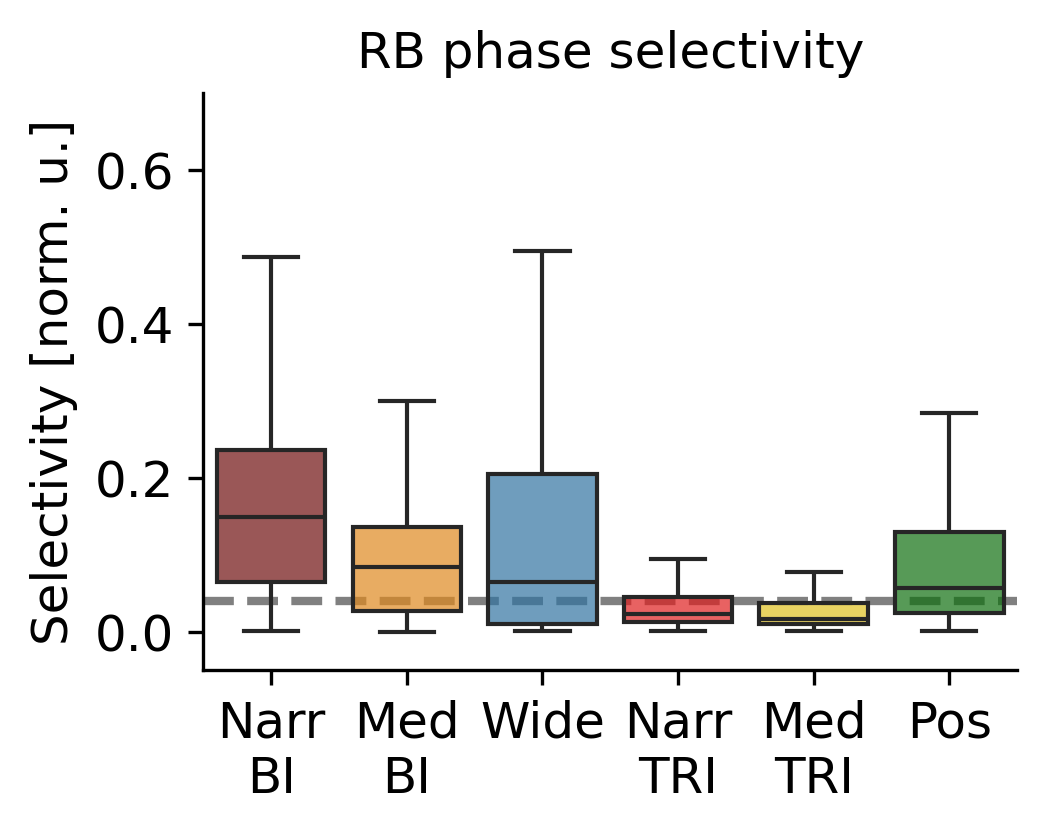

In [23]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

ax.set_title('RB phase selectivity')
set_params['y_select'] = 'norm_RB_phase_selectivity_spikes' # name of the selectivity measure used in the boxplot
set_params['y_name'] = 'Norm. sel.'
set_params['y_label'] = 'Selectivity [norm. u.]'
aux_plot_select_boxplot_fig5(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Selectivity ratios

In [24]:
set_params['boxplot_width'] = 3.5
set_params['boxplot_height'] = 3

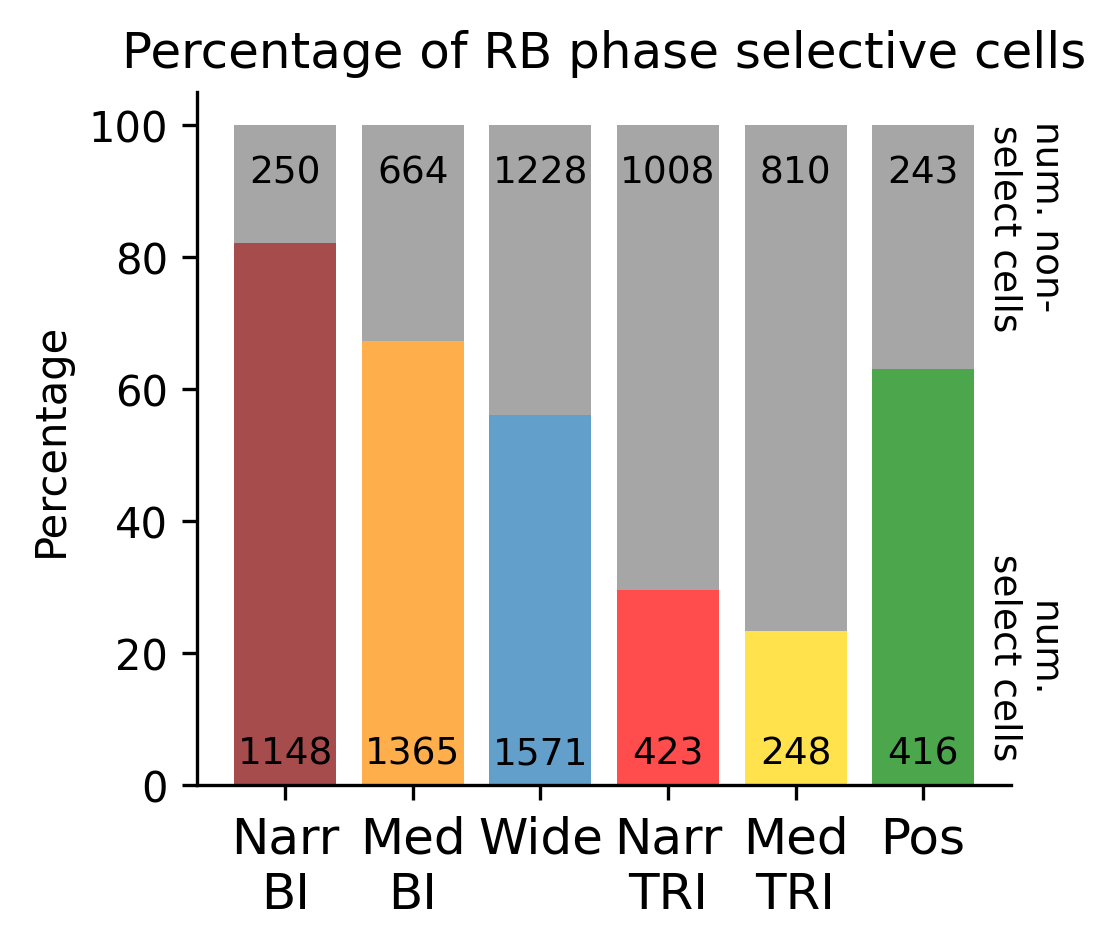

In [25]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

ax.set_title('Percentage of RB phase selective cells')
set_params['y_select'] = 'norm_RB_phase_selectivity_spikes'
aux_plot_select_ratios_fig5(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Testing dominance of POS

In [26]:
classes = df_merged_area['final_class'].unique()

results = []

# Loop over all classes except UP
for cls in classes:
    if cls == 'UP':
        continue
    
    up_vals = df_merged_area.loc[df_merged_area['final_class'] == 'UP',
                                 'norm_RB_phase_selectivity_spikes']
    other_vals = df_merged_area.loc[df_merged_area['final_class'] == cls,
                                    'norm_RB_phase_selectivity_spikes']
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(up_vals, other_vals, alternative='greater')
    
    results.append({
        'comparison': f'UP vs {cls}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_UP': len(up_vals),
        'n_other': len(other_vals)
    })

results_df = pd.DataFrame(results)

# Multiple-testing correction (FDR)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

results_df


,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,UP vs DOWN_narrow_shallow,316475.0,1.000000e+00,659,1398,1.000000e+00
1,UP vs DOWN_medium_shallow,638375.0,9.593850e-01,659,2029,1.000000e+00
2,UP vs DOWN_wide,960325.0,4.943746e-02,659,2799,8.239576e-02
3,UP vs DOWN_medium_sharp,528257.0,1.376586e-72,659,1058,6.882931e-72
4,UP vs DOWN_narrow_sharp,668740.0,1.023140e-53,659,1431,2.557849e-53


In [27]:
results_df['p_fdr'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,UP vs DOWN_narrow_shallow,316475.0,1.000000e+00,659,1398,1.000000e+00
1,UP vs DOWN_medium_shallow,638375.0,9.593850e-01,659,2029,1.000000e+00
2,UP vs DOWN_wide,960325.0,4.943746e-02,659,2799,2.471873e-01
3,UP vs DOWN_medium_sharp,528257.0,1.376586e-72,659,1058,6.882931e-72
4,UP vs DOWN_narrow_sharp,668740.0,1.023140e-53,659,1431,5.115698e-53


### Comparison among L4 units

In [28]:
# Classes of interest
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'norm_RB_phase_selectivity_spikes']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'norm_RB_phase_selectivity_spikes']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2,p_bonf
0,DOWN_wide vs DOWN_narrow_shallow,1445025.0,1.821905e-43,2799,1398,0.064348,0.148631,5.465716e-43
1,DOWN_wide vs DOWN_medium_shallow,2734606.0,2.809569e-02,2799,2029,0.064348,0.083839,8.428708e-02
2,DOWN_narrow_shallow vs DOWN_medium_shallow,1901449.0,1.280755e-64,1398,2029,0.148631,0.083839,3.842265e-64


### Circular histograms

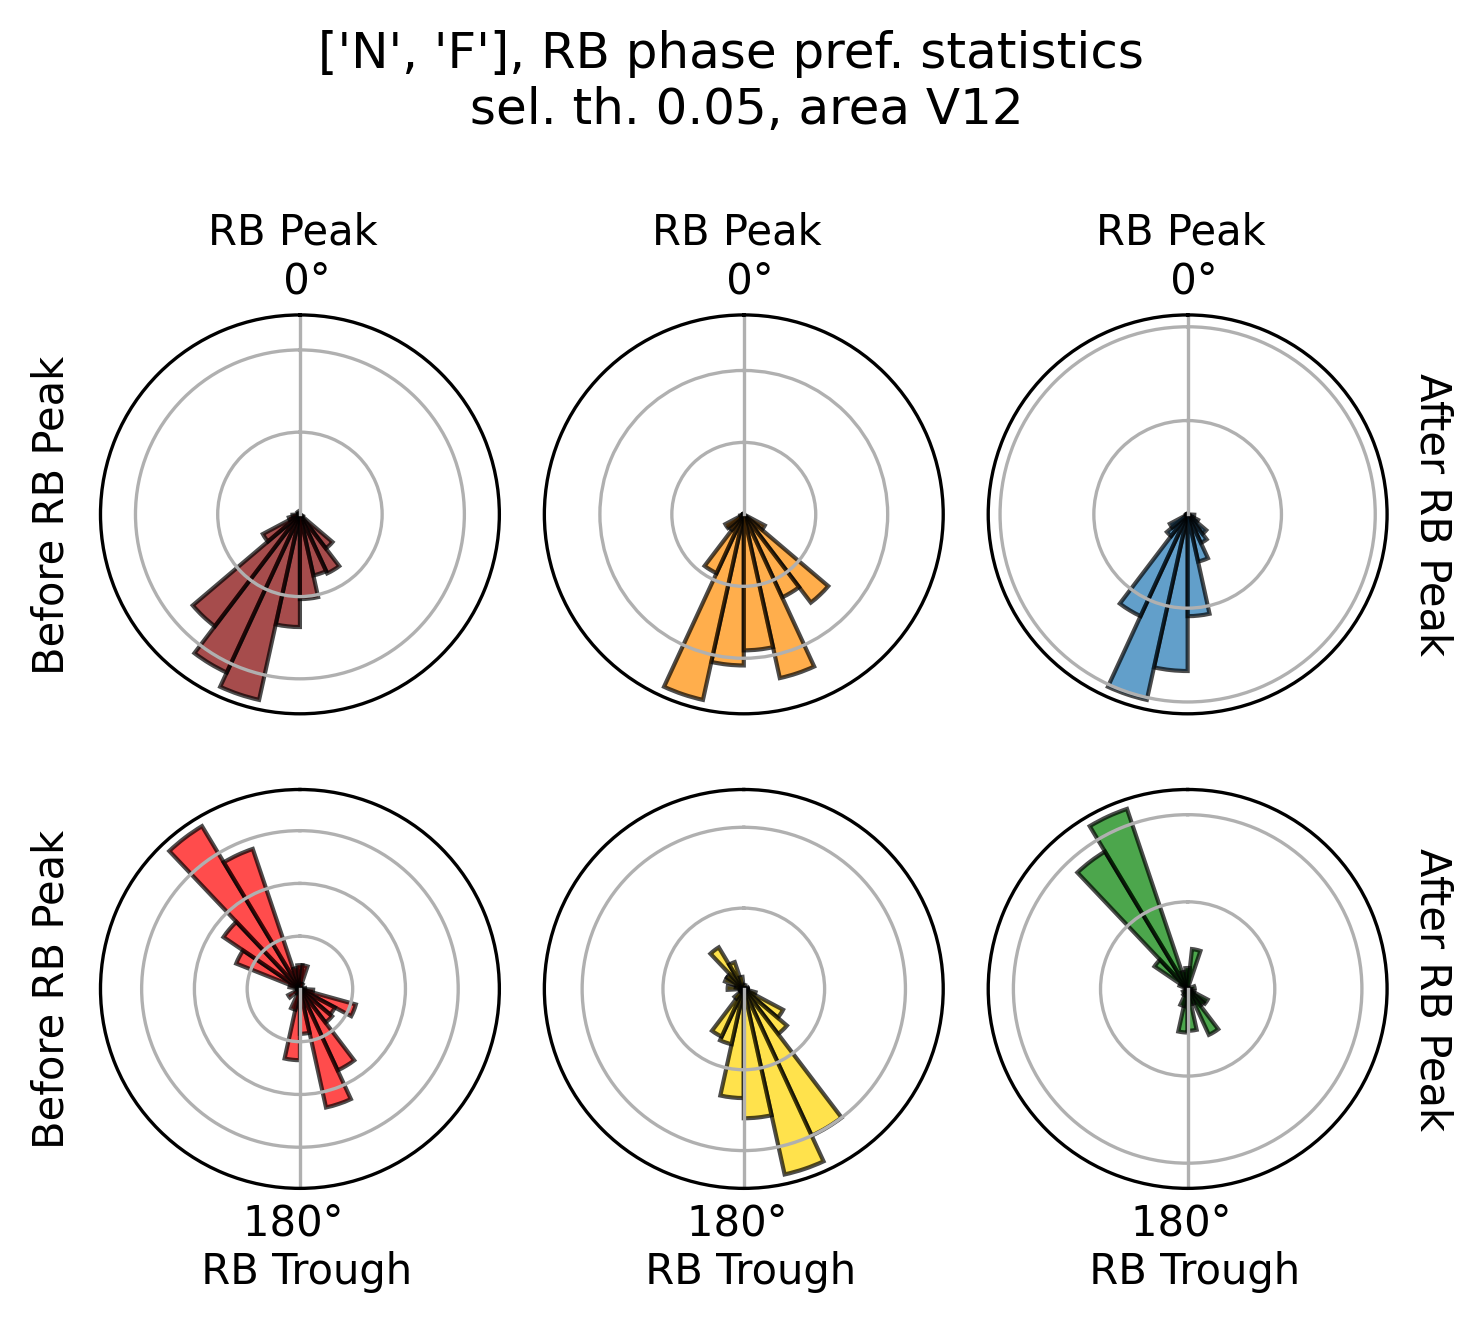

In [29]:
set_params['plot_suptitle'] = f'{MONKEY_LIST}, RB phase pref. statistics \n sel. th. 0.05, area {AREA}'
set_params['pref_phase'] = 'pref_RB_phase_spikes'
set_params['n_bins_hist'] = 30
set_params['font_size'] = 10
plot_CH_panel_fig5(df_merged_area, set_params,save=False,path='')

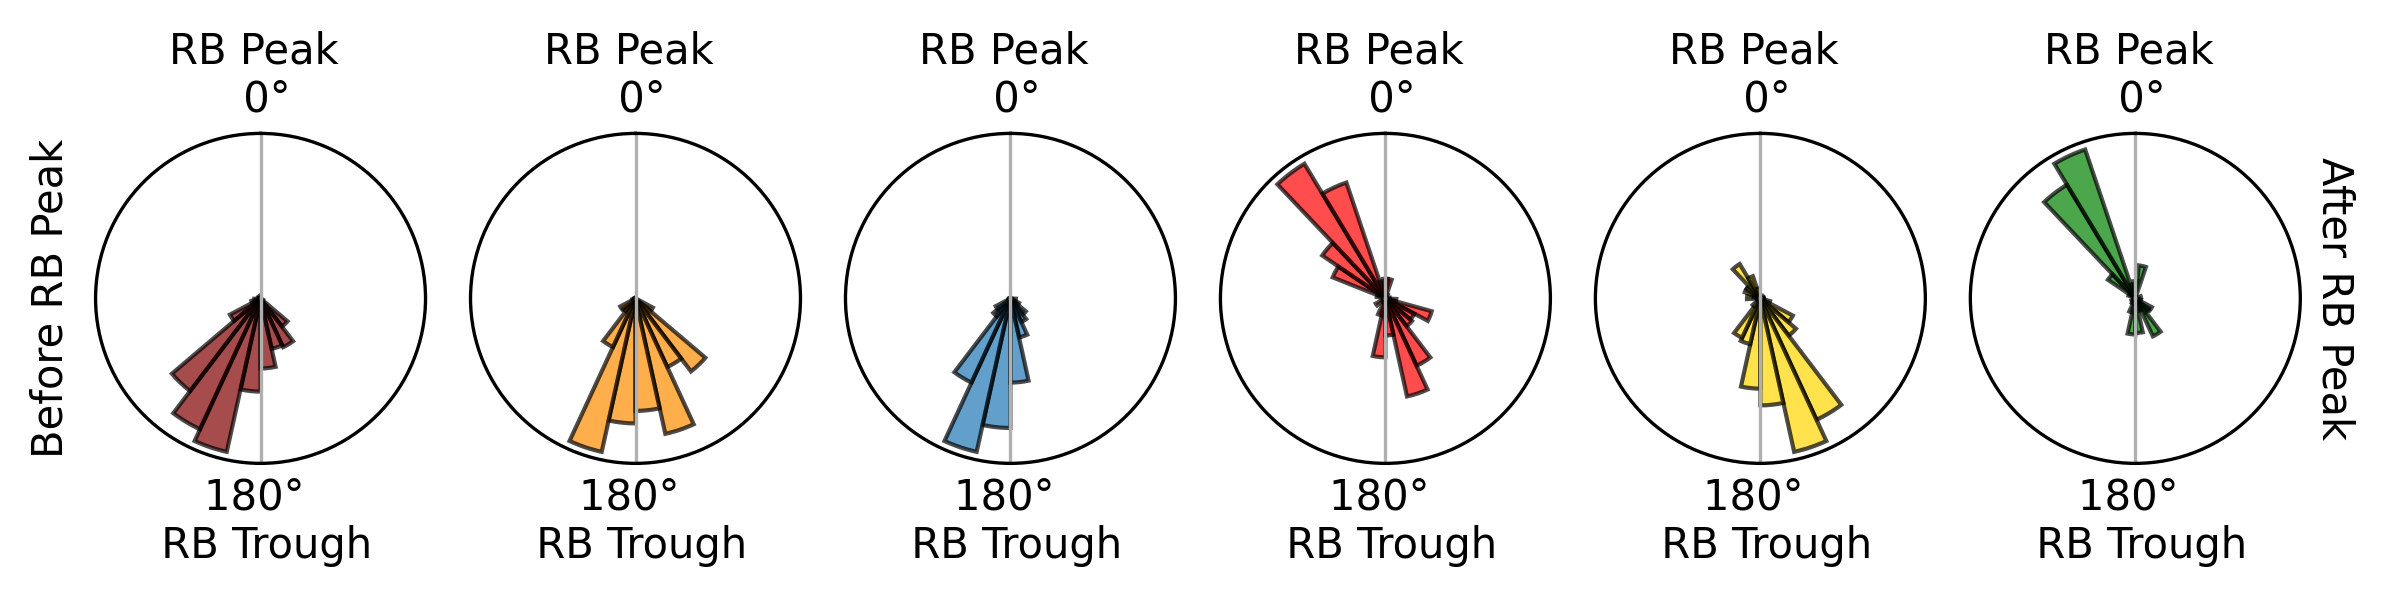

In [30]:
set_params['plot_suptitle'] = ''
plot_CH_panel_fig5_row(df_merged_area, set_params,save=False,path='')

### Phase aligned

In [31]:
# read from the cache rather than hardcoded, so this can never silently
# drift out of sync with the range/bins the histograms were actually built with
MIN_VAL = phase_hist['MIN_VAL']
MAX_VAL = phase_hist['MAX_VAL']
N = phase_hist['N_PI_MULT']
N_BINS = phase_hist['N_BINS']
bin_edges = phase_hist['bin_edges']

In [32]:
def density_hist(counts, bin_edges):
    """Reproduce np.histogram(..., density=True)'s output from raw (poolable) counts."""
    bin_width = bin_edges[1] - bin_edges[0]  # bins are equal-width by construction
    total = counts.sum()
    if total == 0:
        return np.zeros_like(counts, dtype=float)
    return counts / (total * bin_width)

first_peak_hist_dict = {cl: density_hist(phase_hist['counts'][cl]['all'], bin_edges) for cl in FINAL_CLASSES}

In [33]:
select_first_peak_hist_dict = {cl: density_hist(phase_hist['counts'][cl]['selective'], bin_edges) for cl in FINAL_CLASSES}

In [34]:
non_select_first_peak_hist_dict = {cl: density_hist(phase_hist['counts'][cl]['non_selective'], bin_edges) for cl in FINAL_CLASSES}

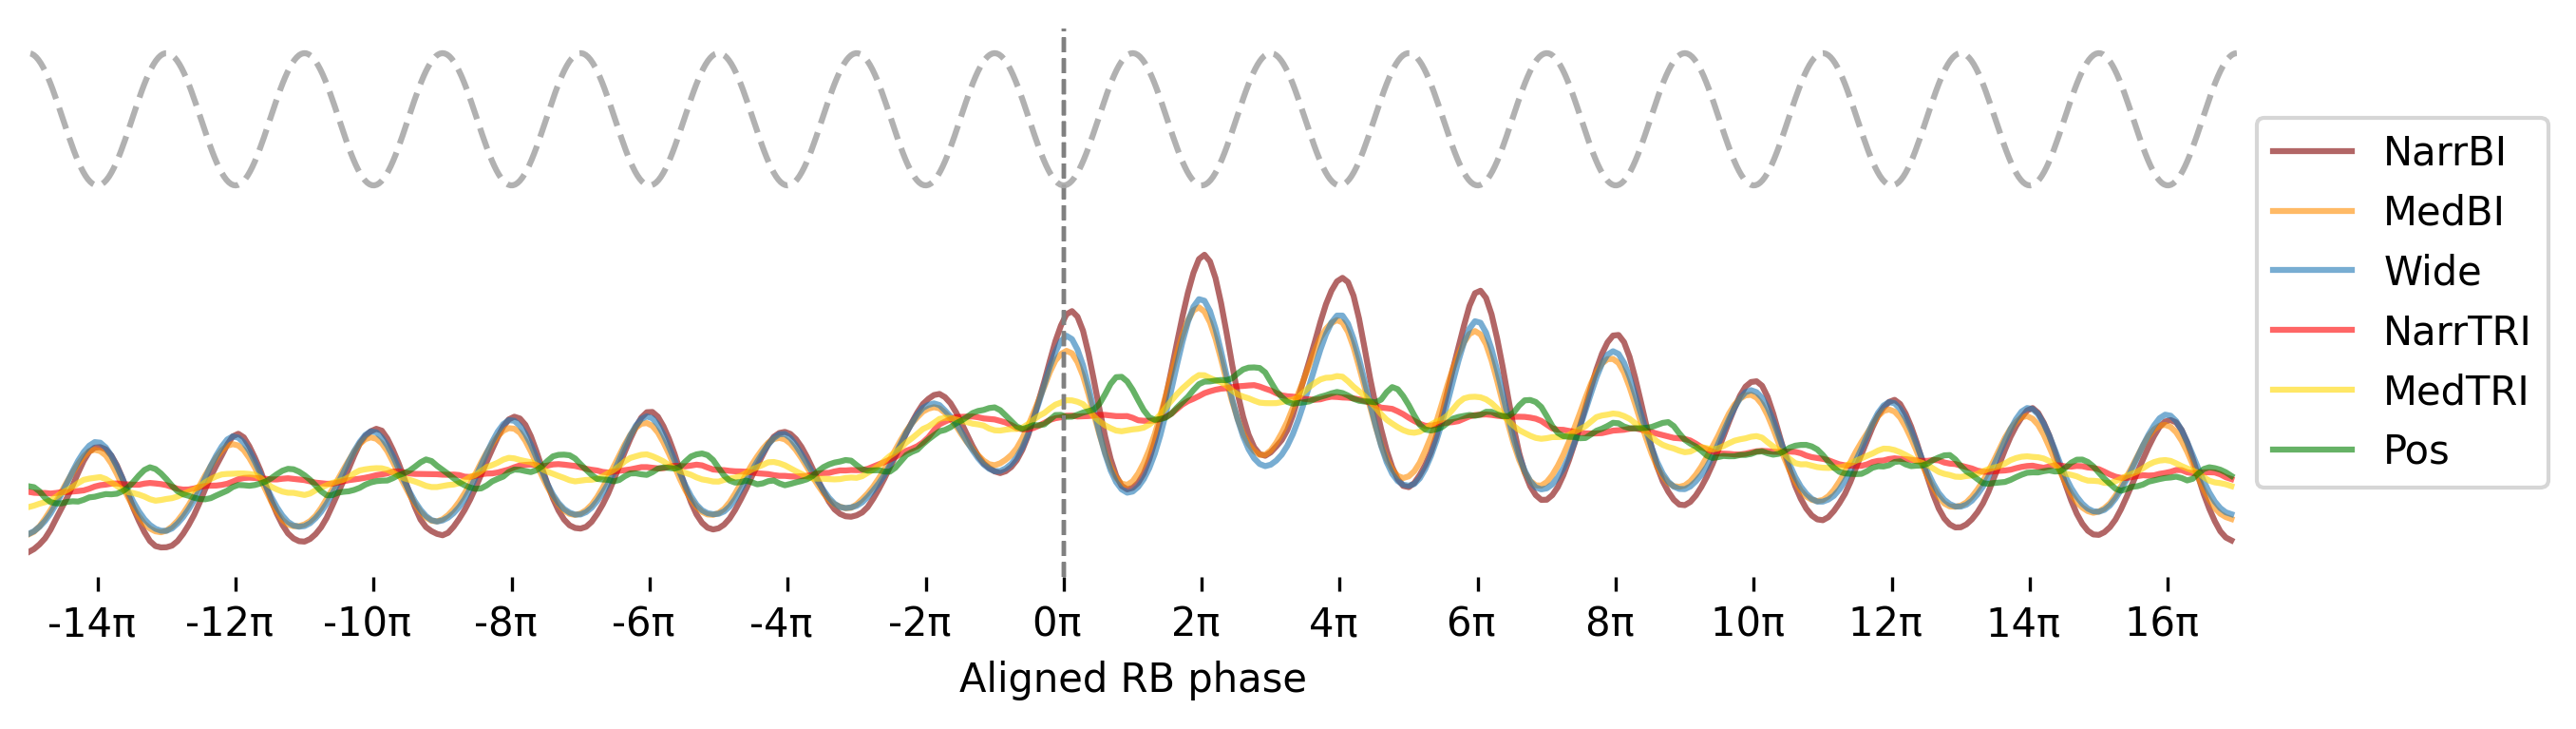

In [35]:
fig, ax = plt.subplots(dpi=300)
fig.set_figheight(2.5)
fig.set_figwidth(10)

#plt.suptitle('All monkeys, first trough aligned phases spikes overlaid \n Gaussian smoothing ')

for idx, cl in enumerate(FINAL_CLASSES):
    n = first_peak_hist_dict[cl]  # already density-normalised, already binned at build time
    data_smooth = gaussian_filter1d(n,sigma=1)
    #data_smooth = (data_smooth-np.min(data_smooth))/(np.max(data_smooth)-np.min(data_smooth))
    ax.plot(bin_edges[:-1],data_smooth,color=CLASS_COLORS[cl],alpha=0.6,label=CLASS_DICT[cl])
    #ax.fill_between(bins[:-1],shift,data_smooth+shift,color=CLASS_COLORS[cl],alpha=0.5)
    ax.set_xlim([MIN_VAL,MAX_VAL])
    ax.axvline(-np.pi,ls='dashed',alpha=1,color='gray',linewidth=1)
    for sp in ['top','bottom','right','left']:
        ax.spines[sp].set_visible(False)
    ax.set_xticks(np.arange(-N+1, N+1 ) * 2*np.pi - np.pi)
    ax.set_xticklabels([f'{int(2*n)}π ' for n in np.arange(-N+1,N+1)])
    ax.set_xlabel('Aligned RB phase')
    ax.set_yticks([])

# plotting sine a an ilustration of the RB phase
x = np.linspace(-(N+1)*2* np.pi, (N)*2*np.pi, 1000)
y = np.cos(x)
ax.plot(x,y*0.002+0.02,color='darkgray',ls='dashed',alpha=0.9)

#plt.tight_layout()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()
plt.close()

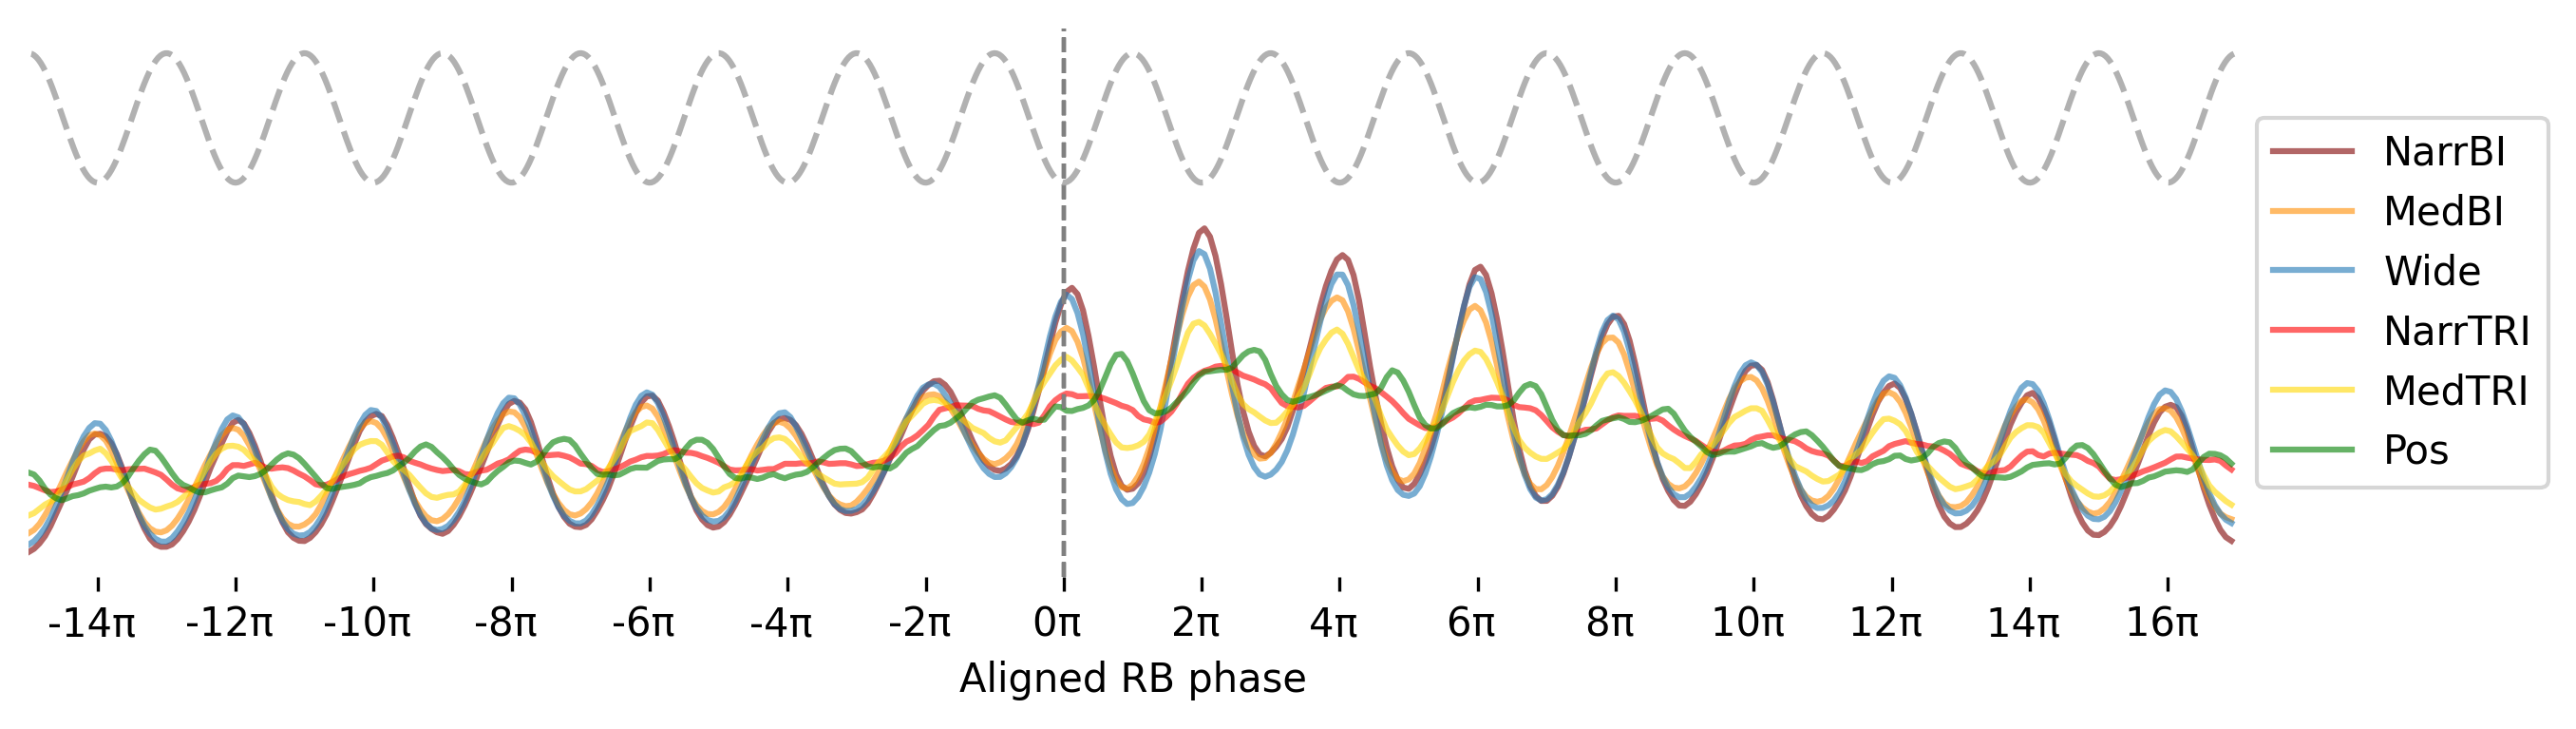

In [36]:
fig, ax = plt.subplots(dpi=300)
fig.set_figheight(2.5)
fig.set_figwidth(10)

#plt.suptitle('All monkeys, first trough aligned phases spikes overlaid \n Gaussian smoothing ')

for idx, cl in enumerate(FINAL_CLASSES):
    n = select_first_peak_hist_dict[cl]  # already density-normalised, already binned at build time
    data_smooth = gaussian_filter1d(n,sigma=1)
    #data_smooth = (data_smooth-np.min(data_smooth))/(np.max(data_smooth)-np.min(data_smooth))
    ax.plot(bin_edges[:-1],data_smooth,color=CLASS_COLORS[cl],alpha=0.6,label=CLASS_DICT[cl])
    #ax.fill_between(bins[:-1],shift,data_smooth+shift,color=CLASS_COLORS[cl],alpha=0.5)
    ax.set_xlim([MIN_VAL,MAX_VAL])
    ax.axvline(-np.pi,ls='dashed',alpha=1,color='gray',linewidth=1)
    for sp in ['top','bottom','right','left']:
        ax.spines[sp].set_visible(False)
    ax.set_xticks(np.arange(-N+1, N+1 ) * 2*np.pi - np.pi)
    ax.set_xticklabels([f'{int(2*n)}π ' for n in np.arange(-N+1,N+1)])
    ax.set_xlabel('Aligned RB phase')
    ax.set_yticks([])

# plotting sine a an ilustration of the RB phase
x = np.linspace(-(N+1)*2* np.pi, (N)*2*np.pi, 1000)
y = np.cos(x)
ax.plot(x,y*0.002+0.02,color='darkgray',ls='dashed',alpha=0.9)

#plt.tight_layout()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()
plt.close()

### FR modulation with high RB envelope

In [37]:
set_params['box_xlabel_fontsize'] = 12  # size of the font at the x axis
set_params['box_xlabel_rotation'] = 0
set_params['box_ylabel_fontsize'] = 12
set_params['box_alpha'] = 0.7
set_params['box_line_width'] = 1
set_params['box_hline_width'] = 2
set_params['boxplot_width'] = 3.5
set_params['boxplot_height'] = 2.5

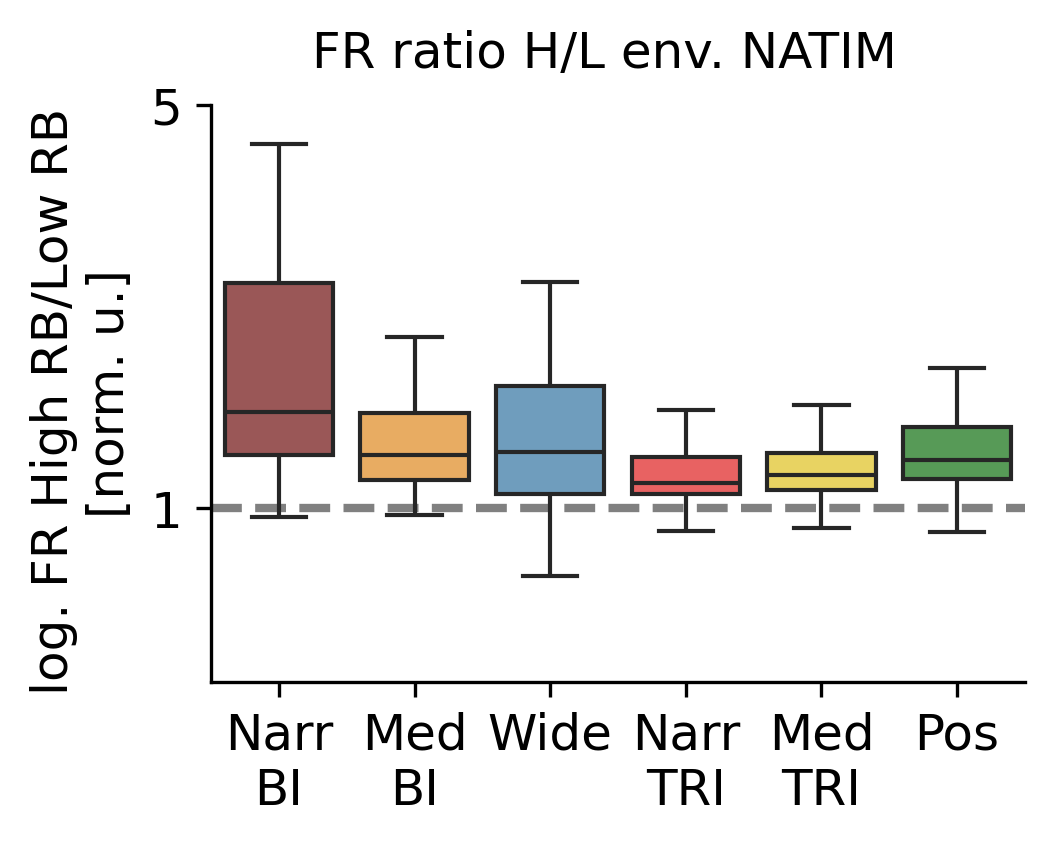

In [38]:
fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(set_params['boxplot_width'])
fig.set_figheight(set_params['boxplot_height'])

set_params['FR_ratio_name'] = 'FR_high_env_low_env_median_ratio'
fig.suptitle('FR ratio H/L env. NATIM')
aux_plot_FR_ratio_boxplot(df_merged_area,ax,set_params)

plt.show()
plt.close()

### Dominace of NarrBI tested

In [48]:
classes = df_merged_area['final_class'].unique()

results = []

# Loop over all classes except UP
for cls in classes:
    if cls == 'DOWN_narrow_shallow':
        continue
    
    up_vals = df_merged_area.loc[df_merged_area['final_class'] == 'DOWN_narrow_shallow',
                                 'FR_high_env_low_env_median_ratio']
    other_vals = df_merged_area.loc[df_merged_area['final_class'] == cls,
                                    'FR_high_env_low_env_median_ratio']
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(up_vals, other_vals, alternative='greater')
    
    results.append({
        'comparison': f'NarrBI vs {cls}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n_UP': len(up_vals),
        'n_other': len(other_vals)
    })

results_df = pd.DataFrame(results)

# Multiple-testing correction (FDR)
results_df['p_fdr'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,NarrBI vs DOWN_medium_shallow,1928998.5,2.784471e-72,1398,2029,4.640785e-72
1,NarrBI vs DOWN_wide,2589619.5,6.046116e-66,1398,2799,7.557645e-66
2,NarrBI vs DOWN_medium_sharp,1192594.0,1.023727e-149,1398,1058,2.559317e-149
3,NarrBI vs DOWN_narrow_sharp,1651040.5,1.595300e-197,1398,1431,7.976501e-197
4,NarrBI vs UP,654428.0,6.307030e-54,1398,659,6.307030e-54


In [49]:
results_df['p_fdr'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n_UP,n_other,p_fdr
0,NarrBI vs DOWN_medium_shallow,1928998.5,2.784471e-72,1398,2029,1.392236e-71
1,NarrBI vs DOWN_wide,2589619.5,6.046116e-66,1398,2799,3.023058e-65
2,NarrBI vs DOWN_medium_sharp,1192594.0,1.023727e-149,1398,1058,5.118635e-149
3,NarrBI vs DOWN_narrow_sharp,1651040.5,1.595300e-197,1398,1431,7.976501e-197
4,NarrBI vs UP,654428.0,6.307030e-54,1398,659,3.153515e-53


### Comparison among L4 units

In [41]:
# Classes of interest
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bonferroni correction
results_df['p_bonf'] = multipletests(results_df['p_value'], method='bonferroni')[1]

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2,p_bonf
0,DOWN_wide vs DOWN_narrow_shallow,1323382.5,1.209223e-65,2799,1398,1.251225,1.466940,3.627670e-65
1,DOWN_wide vs DOWN_medium_shallow,2767673.0,1.325162e-01,2799,2029,1.251225,1.238565,3.975486e-01
2,DOWN_narrow_shallow vs DOWN_medium_shallow,1928998.5,5.568942e-72,1398,2029,1.466940,1.238565,1.670683e-71


### Group comparison for L4 + POS units, just one test

In [42]:
down_classes = ['DOWN_wide', 'DOWN_narrow_shallow', 'DOWN_medium_shallow'] # 'UP'
groups = [
    df_merged_area.loc[df_merged_area['final_class'] == cls,
                       'FR_high_env_low_env_median_ratio']
    for cls in down_classes
]

stat, p = kruskal(*groups)
print(stat, p)


374.0241484379114 6.04906313635129e-82


### Pairwise testing in L4, FR

In [43]:
pairs = list(itertools.combinations(down_classes, 2))

results = []
for a, b in pairs:
    g1 = df_merged_area.loc[df_merged_area['final_class'] == a,
                            'FR_high_env_low_env_median_ratio']
    g2 = df_merged_area.loc[df_merged_area['final_class'] == b,
                            'FR_high_env_low_env_median_ratio']
    
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    results.append([a, b, stat, p])

df_results = pd.DataFrame(results, columns=["Group A", "Group B", "U", "p_raw"])

# Bonferroni correction (3 comparisons → multiply p by 3)
df_results["p_bonferroni"] = df_results["p_raw"] * len(df_results)
df_results["p_bonferroni"] = df_results["p_bonferroni"].clip(upper=1.0)

df_results

,Group A,Group B,U,p_raw,p_bonferroni
0,DOWN_wide,DOWN_narrow_shallow,1323382.5,1.209223e-65,3.627670e-65
1,DOWN_wide,DOWN_medium_shallow,2767673.0,1.325162e-01,3.975486e-01
2,DOWN_narrow_shallow,DOWN_medium_shallow,1928998.5,5.568942e-72,1.670683e-71


### Biphasic VS Triphasic testing 

In [44]:
# Classes of interest
down_classes = ['DOWN_narrow_shallow', 'DOWN_narrow_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_narrow_shallow vs DOWN_narrow_sharp,1651040.5,1.595300e-197,1398,1431,1.46694,1.106266


In [45]:
# Classes of interest
down_classes = ['DOWN_medium_shallow', 'DOWN_medium_sharp']

results = []

# Loop over all pairwise combinations
for cls1, cls2 in combinations(down_classes, 2):
    
    vals1 = df_merged_area.loc[df_merged_area['final_class'] == cls1,
                               'FR_high_env_low_env_median_ratio']
    vals2 = df_merged_area.loc[df_merged_area['final_class'] == cls2,
                               'FR_high_env_low_env_median_ratio']
    
    # Mann–Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals1, vals2, alternative='greater')
    
    results.append({
        'comparison': f'{cls1} vs {cls2}',
        'u_stat': u_stat,
        'p_value': p_val,
        'n1': len(vals1),
        'n2': len(vals2),
        'median1': vals1.median(),
        'median2': vals2.median()
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df

,comparison,u_stat,p_value,n1,n2,median1,median2
0,DOWN_medium_shallow vs DOWN_medium_sharp,1398065.0,1.020719e-43,2029,1058,1.238565,1.144669
